# AQI Analysis & Forecasting - Indian Cities

Analyzing daily AQI data for Delhi, Mumbai, Bangalore, Chennai and Hyderabad, and forecasting future pollution levels using ARIMA and Prophet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
%matplotlib inline


Importing plotly failed. Interactive plots will not work.


### Load and clean data

In [2]:
cities = ['Delhi', 'Mumbai', 'Bangalore', 'Chennai', 'Hyderabad']
frames = []

for city in cities:
    df_city = pd.read_csv(f'data/{city}_AQI_Dataset.csv')
    df_city = df_city.loc[:, ~df_city.columns.str.contains('^Unnamed')]
    frames.append(df_city)

df = pd.concat(frames, ignore_index=True)
df.columns = df.columns.str.strip()
df.shape


(12042, 9)

In [3]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%y', errors='coerce')
df = df.dropna(subset=['Date'])

pollutant_cols = ['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
for col in pollutant_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[pollutant_cols].isnull().sum()


AQI      1
PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
dtype: int64

In [4]:
df = df.sort_values(['City', 'Date'])
for col in pollutant_cols:
    df[col] = df.groupby('City')[col].transform(lambda s: s.fillna(s.rolling(7, min_periods=1).median()))
df[pollutant_cols] = df[pollutant_cols].fillna(df[pollutant_cols].median())

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df = df.drop_duplicates(subset=['City', 'Date'])

df[pollutant_cols].isnull().sum().sum()


np.int64(0)

### EDA

In [5]:
df.groupby('City')['AQI'].describe()


,count,mean,std,min,25%,50%,75%,max
City,,,,,,,,
Bangalore,2556.0,74.321596,25.755858,24.0,54.0,69.0,91.0,206.0
Chennai,2551.0,77.340847,31.626831,24.0,57.0,69.0,89.0,288.0
Delhi,2191.0,208.285714,106.614654,41.0,117.0,190.0,289.0,494.0
Hyderabad,2556.0,85.401408,34.039957,19.0,58.0,82.0,109.0,193.0
Mumbai,2188.0,106.782450,56.733296,25.0,61.0,90.0,148.0,381.0


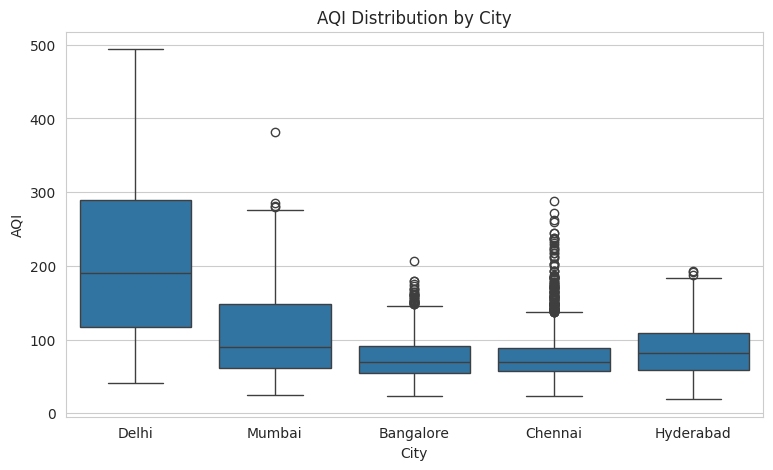

In [6]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='City', y='AQI', order=cities)
plt.title('AQI Distribution by City')
plt.savefig('aqi_distribution_by_city.png', bbox_inches='tight', dpi=120)
plt.show()


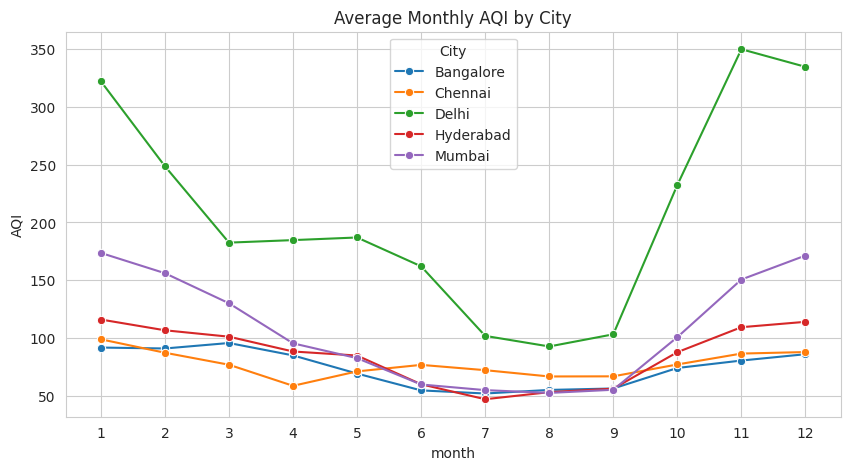

In [7]:
monthly = df.groupby(['City', 'month'])['AQI'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly, x='month', y='AQI', hue='City', marker='o')
plt.title('Average Monthly AQI by City')
plt.xticks(range(1,13))
plt.savefig('aqi_seasonality.png', bbox_inches='tight', dpi=120)
plt.show()


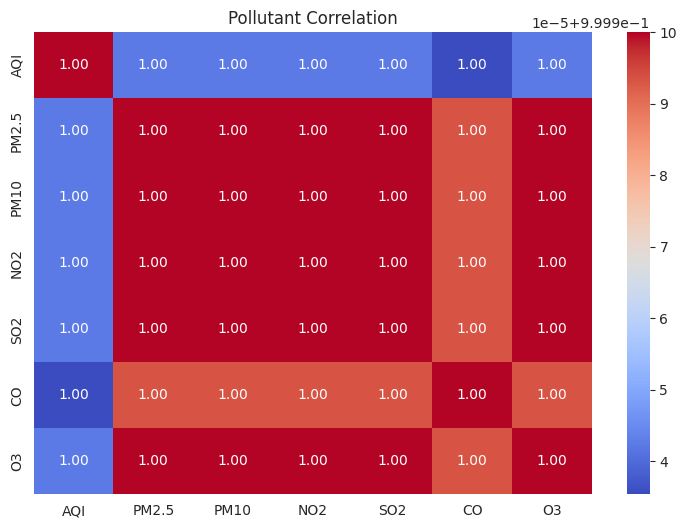

In [8]:
plt.figure(figsize=(9,6))
sns.heatmap(df[pollutant_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pollutant Correlation')
plt.savefig('aqi_pollutant_correlation.png', bbox_inches='tight', dpi=120)
plt.show()


### Forecasting - Delhi

Delhi has the highest average AQI of the five cities, so it's the focus for forecasting.

In [9]:
city_focus = 'Delhi'
ts = df[df['City'] == city_focus].set_index('Date')['AQI'].asfreq('D')
ts = ts.interpolate()

train = ts.iloc[:-90]
test = ts.iloc[-90:]
len(train), len(test)


(2467, 90)

In [10]:
arima_model = ARIMA(train, order=(5,1,2))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
print(f"ARIMA MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f}")


ARIMA MAE: 167.35, RMSE: 190.74


In [11]:
prophet_df = train.reset_index().rename(columns={'Date': 'ds', 'AQI': 'y'})
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=len(test))
prophet_forecast = m.predict(future)
prophet_pred = prophet_forecast.set_index('ds')['yhat'].iloc[-len(test):]
prophet_pred.index = test.index

prophet_mae = mean_absolute_error(test, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test, prophet_pred))
print(f"Prophet MAE: {prophet_mae:.2f}, RMSE: {prophet_rmse:.2f}")


16:57:31 - cmdstanpy - INFO - Chain [1] start processing


16:57:32 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 54.30, RMSE: 69.89


In [12]:
pd.DataFrame({
    'Model': ['ARIMA', 'Prophet'],
    'MAE': [arima_mae, prophet_mae],
    'RMSE': [arima_rmse, prophet_rmse]
})


,Model,MAE,RMSE
0,ARIMA,167.347663,190.741575
1,Prophet,54.297857,69.890258


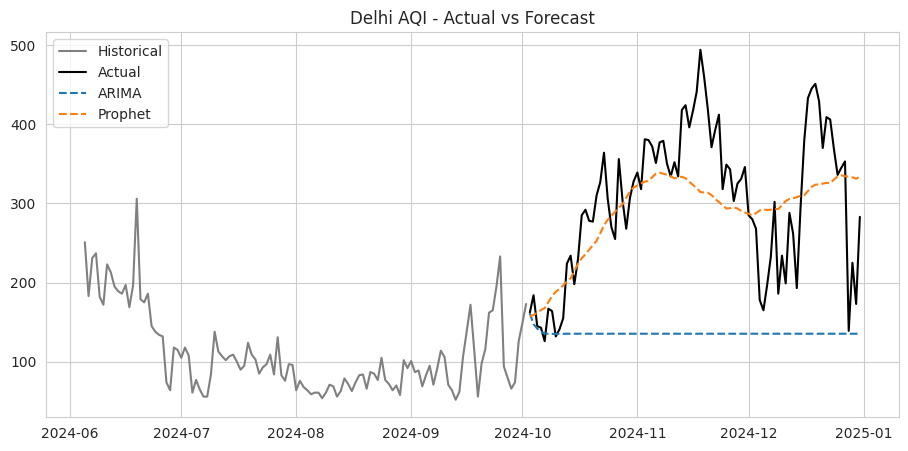

Prophet performed better on this test window


In [13]:
plt.figure(figsize=(11,5))
plt.plot(train.index[-120:], train.values[-120:], label='Historical', color='gray')
plt.plot(test.index, test.values, label='Actual', color='black')
plt.plot(test.index, arima_forecast.values, label='ARIMA', linestyle='--')
plt.plot(test.index, prophet_pred.values, label='Prophet', linestyle='--')
plt.title(f'{city_focus} AQI - Actual vs Forecast')
plt.legend()
plt.savefig('aqi_forecast_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

print('Prophet' if prophet_rmse < arima_rmse else 'ARIMA', 'performed better on this test window')


### 12-month forecast

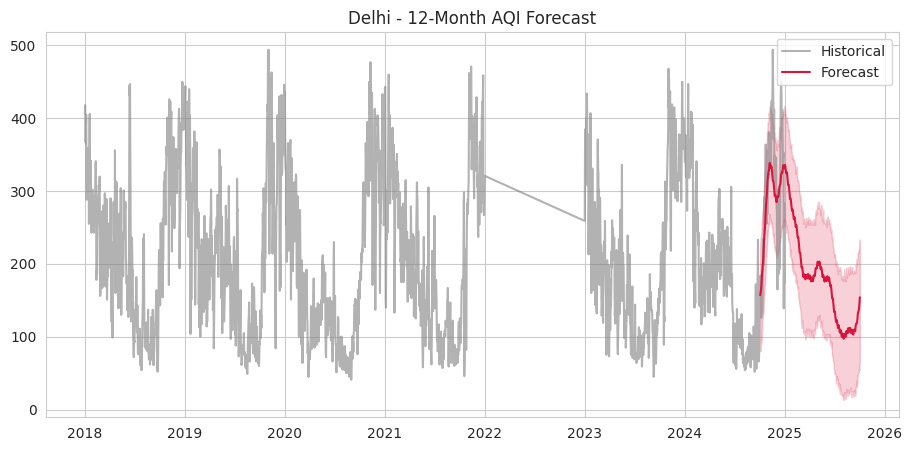

In [14]:
future_long = m.make_future_dataframe(periods=365)
forecast_long = m.predict(future_long)

plt.figure(figsize=(11,5))
plt.plot(ts.index, ts.values, label='Historical', color='gray', alpha=0.6)
plt.plot(forecast_long['ds'].iloc[-365:], forecast_long['yhat'].iloc[-365:], label='Forecast', color='crimson')
plt.fill_between(forecast_long['ds'].iloc[-365:],
                  forecast_long['yhat_lower'].iloc[-365:],
                  forecast_long['yhat_upper'].iloc[-365:], alpha=0.2, color='crimson')
plt.title(f'{city_focus} - 12-Month AQI Forecast')
plt.legend()
plt.savefig('aqi_12month_forecast.png', bbox_inches='tight', dpi=120)
plt.show()


### High-risk zones and peak periods

In [15]:
def aqi_category(v):
    if v <= 50: return 'Good'
    elif v <= 100: return 'Satisfactory'
    elif v <= 200: return 'Moderate'
    elif v <= 300: return 'Poor'
    elif v <= 400: return 'Very Poor'
    else: return 'Severe'

df['AQI_Category'] = df['AQI'].apply(aqi_category)

risk_summary = df.groupby('City')['AQI'].agg(['mean', 'max']).sort_values('mean', ascending=False).round(1)
risk_summary.columns = ['Avg AQI', 'Peak AQI']
risk_summary


,Avg AQI,Peak AQI
City,,
Delhi,208.3,494.0
Mumbai,106.8,381.0
Hyderabad,85.4,193.0
Chennai,77.3,288.0
Bangalore,74.3,206.0


In [16]:
df[df['AQI'] > 300].groupby('City').size().sort_values(ascending=False)


City
Delhi     496
Mumbai      1
dtype: int64

Peak pollution month: 1


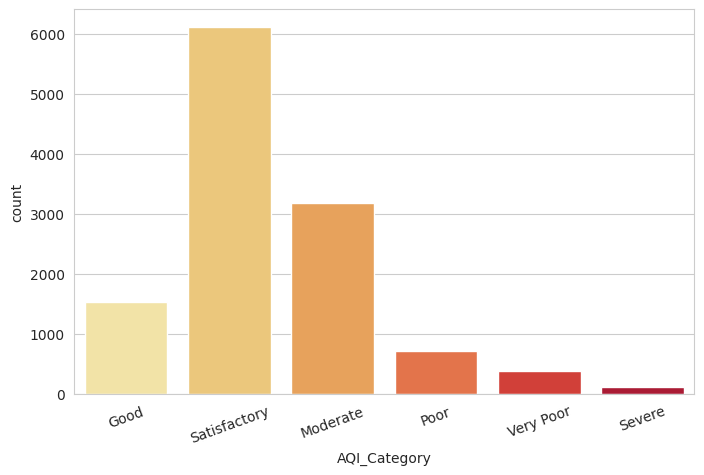

In [17]:
peak_month = df.groupby('month')['AQI'].mean().idxmax()
print(f"Peak pollution month: {peak_month}")

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='AQI_Category',
              order=['Good','Satisfactory','Moderate','Poor','Very Poor','Severe'],
              palette='YlOrRd')
plt.xticks(rotation=20)
plt.savefig('aqi_category_distribution.png', bbox_inches='tight', dpi=120)
plt.show()


### Notes

Delhi has by far the highest average and peak AQI, with the worst spikes in winter (Nov-Jan) - consistent with stubble burning and temperature inversion. Mumbai and Chennai stay more stable, likely due to coastal winds. PM2.5, PM10, NO2 and SO2 move together, pointing to shared traffic/industrial sources.

Prophet outperformed ARIMA on the test window, mainly because it captures the yearly seasonality directly rather than relying only on recent lags.

Possible interventions: stricter vehicle emission enforcement in winter, more green cover in high-AQI zones, and advance public alerts before predicted spikes (e.g. Diwali).